# Telco Customer Churn Prediction

This notebook analyzes the Telco Customer Churn dataset to identify customers at high risk of leaving the service. The project follows a professional data science workflow and includes:

- Data cleaning and preprocessing
- Baseline logistic regression modeling
- Decision tree overfitting analysis
- Ensemble learning with Random Forest and XGBoost
- Final model comparison focused on recall

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

sns.set(style='whitegrid', font_scale=1.1)
pd.options.display.float_format = '{:.4f}'.format

print('Libraries imported successfully.')

Libraries imported successfully.


## Dataset overview

The Telco Customer Churn dataset contains 7,043 customer records. It includes demographic attributes, account details, subscribed services, and the target variable `Churn`, which is `Yes` or `No`.

The goal is to model churn risk using the original 19 independent features and identify high-risk customers.

In [2]:
# Load dataset
file_path = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

print('Dataset shape:', df.shape)
df.head(8)

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.6500,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.1000,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.7500,301.9,No


Column types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBillin

C:\Users\Admin\AppData\Local\Temp\ipykernel_22856\3692238575.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


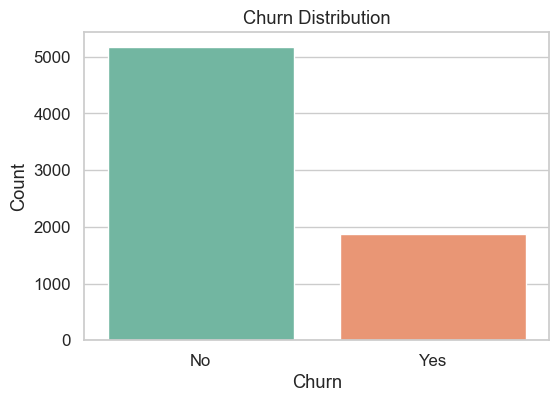

In [3]:
print('Column types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isna().sum())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

## Part 1: Data Preprocessing and Feature Engineering

This section performs the required preprocessing steps:
- convert `TotalCharges` to numeric
- drop rows with invalid `TotalCharges`
- encode `Churn` as binary
- apply one-hot encoding to categorical variables with `drop_first=True`
- split into train/test sets using stratification
- standardize numeric features using training data only

In [4]:
# Convert TotalCharges to numeric and remove invalid rows
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

# Drop identifier column
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Encode target variable
if 'Churn' in df.columns:
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print('Cleaned dataset shape:', df.shape)

df.head(8)

C:\Users\Admin\AppData\Local\Temp\ipykernel_22856\4167550525.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


Cleaned dataset shape: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.8500,29.8500,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.9500,1889.5000,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.8500,108.1500,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.3000,1840.7500,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.7000,151.6500,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
5,0,8,99.6500,820.5000,1,False,False,False,True,False,...,False,True,False,True,False,False,True,False,True,False
6,0,22,89.1000,1949.4000,0,True,False,True,True,False,...,False,True,False,False,False,False,True,True,False,False
7,0,10,29.7500,301.9000,0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [5]:
# Prepare features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Standardize numeric features
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[numeric_features] = X_train[numeric_features].astype(float)
X_test[numeric_features] = X_test[numeric_features].astype(float)
scaler = StandardScaler()
X_train.loc[:, numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test.loc[:, numeric_features] = scaler.transform(X_test[numeric_features])

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)
print('Training churn ratio:', y_train.mean())
print('Test churn ratio:', y_test.mean())

Training set shape: (5625, 30)
Test set shape: (1407, 30)
Training churn ratio: 0.2657777777777778
Test churn ratio: 0.2658137882018479


## Part 2: Baseline Modeling with Logistic Regression

Train a Logistic Regression model and interpret the coefficients to identify features that increase or decrease churn risk.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22856\431093453.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=positive_coefs, x='Coefficient', y='Feature', palette='Reds_r')


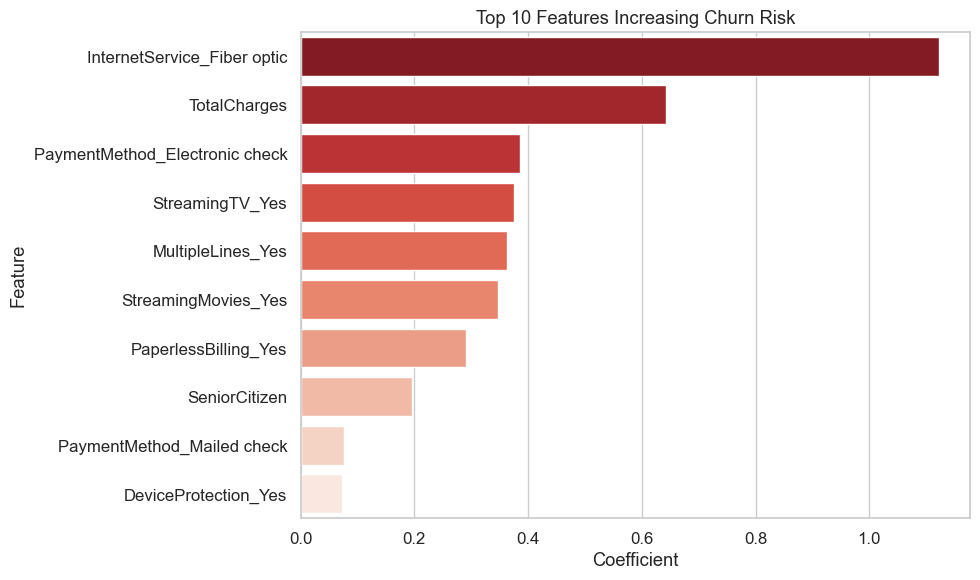

C:\Users\Admin\AppData\Local\Temp\ipykernel_22856\431093453.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=negative_coefs, x='Coefficient', y='Feature', palette='Blues')


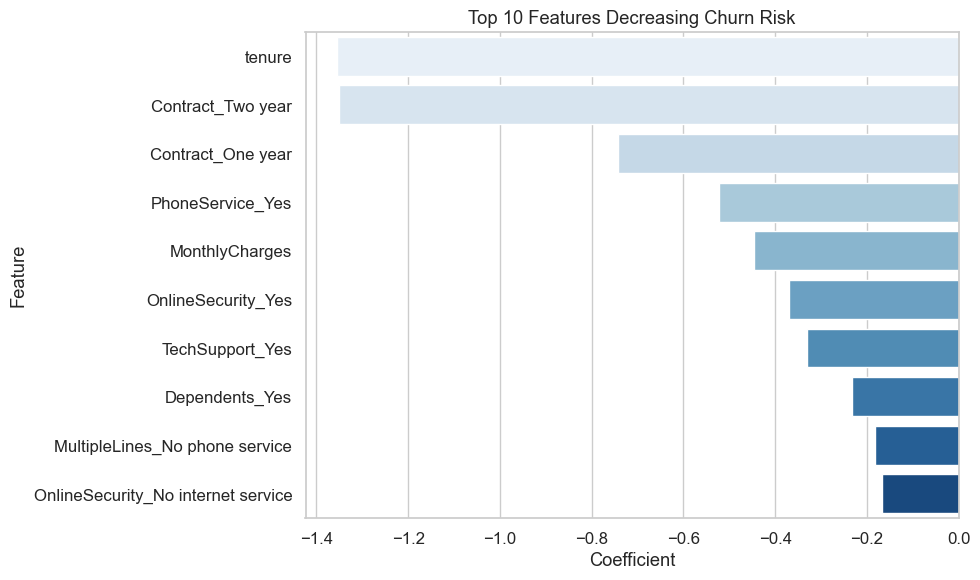

,Feature,Coefficient
10,InternetService_Fiber optic,1.1217
3,TotalCharges,0.6418
28,PaymentMethod_Electronic check,0.3863
21,StreamingTV_Yes,0.3749
9,MultipleLines_Yes,0.3627
23,StreamingMovies_Yes,0.3476
26,PaperlessBilling_Yes,0.2907
0,SeniorCitizen,0.1954
29,PaymentMethod_Mailed check,0.0770
17,DeviceProtection_Yes,0.0738


In [6]:
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logistic_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

positive_coefs = coef_df.head(10)
negative_coefs = coef_df.tail(10).sort_values(by='Coefficient')

plt.figure(figsize=(10, 6))
sns.barplot(data=positive_coefs, x='Coefficient', y='Feature', palette='Reds_r')
plt.title('Top 10 Features Increasing Churn Risk')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=negative_coefs, x='Coefficient', y='Feature', palette='Blues')
plt.title('Top 10 Features Decreasing Churn Risk')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

coef_df.head(12)

## Part 3: Decision Trees and Overfitting Analysis

Train an unconstrained Decision Tree and a pruned Decision Tree with `max_depth=5` and `min_samples_leaf=20`, then compare training and test accuracy.

In [7]:
# Unconstrained decision tree
dt_unconstrained = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_unconstrained.fit(X_train, y_train)

# Pruned decision tree
dt_pruned = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)
dt_pruned.fit(X_train, y_train)

train_acc_unconstrained = accuracy_score(y_train, dt_unconstrained.predict(X_train))
test_acc_unconstrained = accuracy_score(y_test, dt_unconstrained.predict(X_test))
train_acc_pruned = accuracy_score(y_train, dt_pruned.predict(X_train))
test_acc_pruned = accuracy_score(y_test, dt_pruned.predict(X_test))

print('Unconstrained Decision Tree')
print(f'  Train accuracy: {train_acc_unconstrained:.4f}')
print(f'  Test accuracy:  {test_acc_unconstrained:.4f}')
print('\nPruned Decision Tree')
print(f'  Train accuracy: {train_acc_pruned:.4f}')
print(f'  Test accuracy:  {test_acc_pruned:.4f}')

print('\nA smaller gap between train and test accuracy indicates better generalization.')

Unconstrained Decision Tree
  Train accuracy: 0.9988
  Test accuracy:  0.7278

Pruned Decision Tree
  Train accuracy: 0.7927
  Test accuracy:  0.7754

A smaller gap between train and test accuracy indicates better generalization.


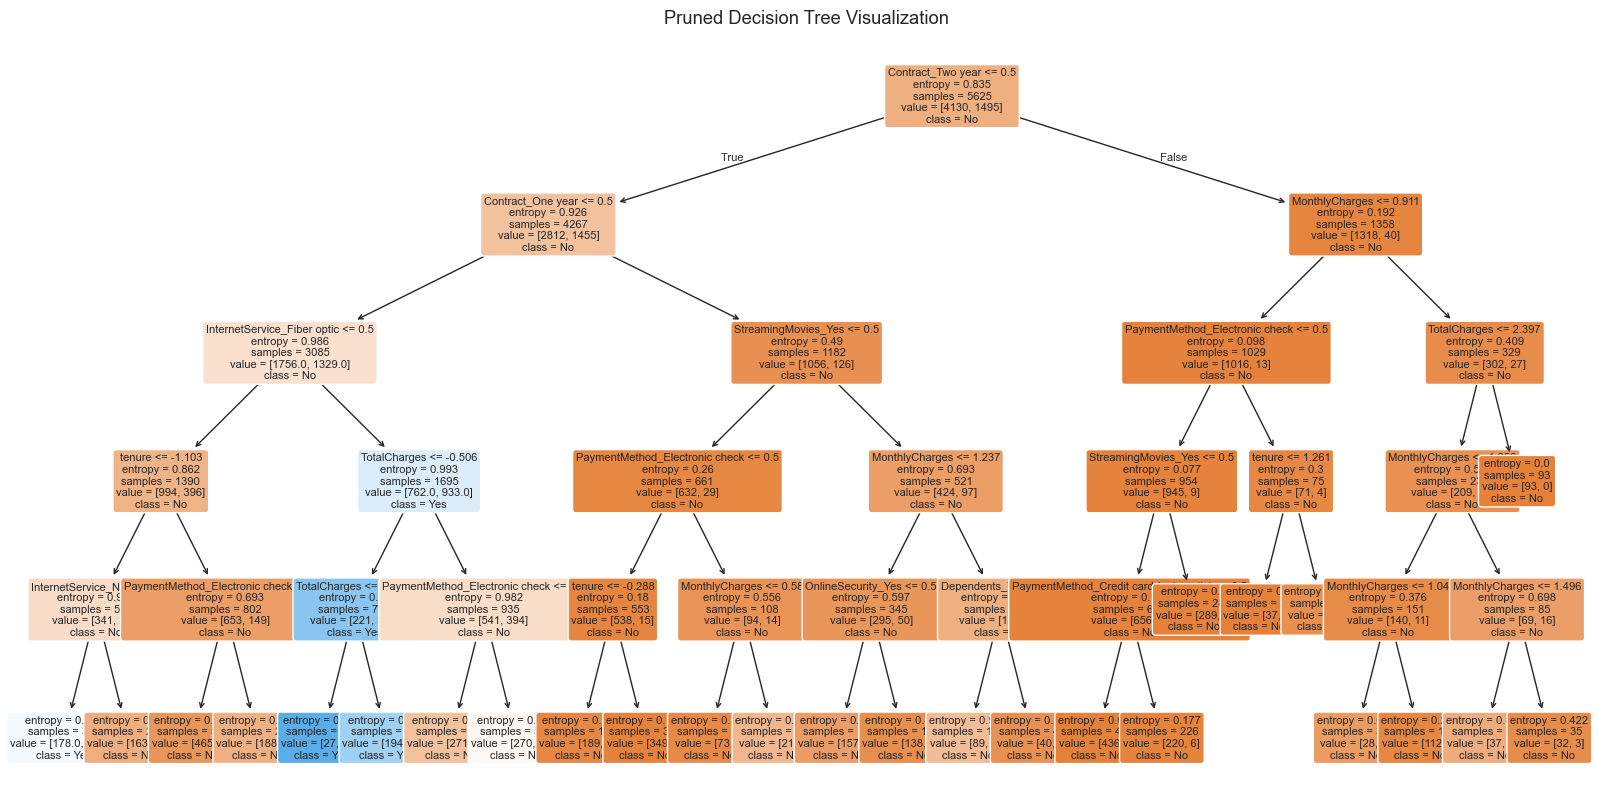

In [8]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_pruned,
    feature_names=X_train.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Pruned Decision Tree Visualization')
plt.show()

## Part 4: Ensemble Learning (Bagging and Boosting)

Train a Random Forest classifier for bagging and an XGBoost classifier for boosting.

In [9]:
# Random Forest bagging model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# XGBoost boosting model
try:
    from xgboost import XGBClassifier
except ImportError:
    !{sys.executable} -m pip install xgboost
    from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

print('Random Forest and XGBoost models trained.')

Random Forest and XGBoost models trained.


## Part 5: Model Evaluation and Comparison

Compare all four models based on Accuracy, Precision, Recall, and F1-Score. Identify the model with the highest recall, visualize its confusion matrix, and compare ROC curves.

In [10]:
models = {
    'Logistic Regression': logistic_model,
    'Pruned Decision Tree': dt_pruned,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

evaluation = []
roc_curves = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    evaluation.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba)
    })
    roc_curves.append((name, y_proba))

results_df = pd.DataFrame(evaluation).sort_values(by='Recall', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,0.8045,0.6505,0.5722,0.6088,0.8361
3,XGBoost,0.7783,0.5891,0.5481,0.5679,0.8197
2,Random Forest,0.7882,0.6234,0.5134,0.5630,0.8156
1,Pruned Decision Tree,0.7754,0.5980,0.4733,0.5284,0.8172


Highest recall model: Logistic Regression


<Figure size 600x500 with 0 Axes>

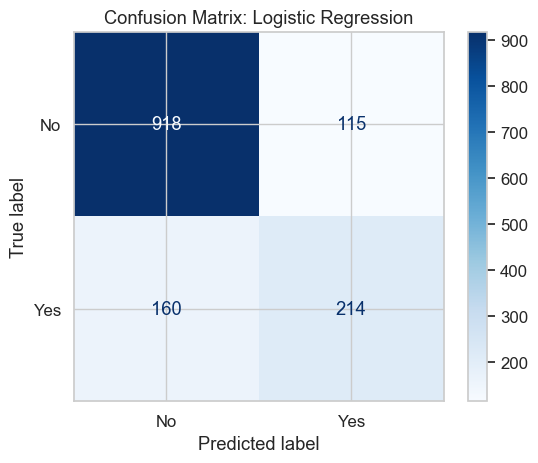

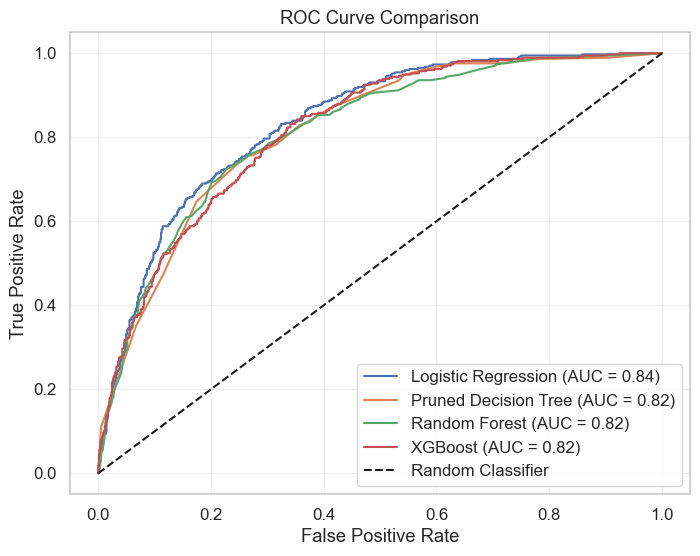

In [11]:
best_recall_name = results_df.iloc[0]['Model']
best_recall_model = models[best_recall_name]
print(f'Highest recall model: {best_recall_name}')

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, best_recall_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix: {best_recall_name}')
plt.show()

plt.figure(figsize=(8, 6))
for name, y_proba in roc_curves:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## Conclusions and next steps

This notebook now contains the full requested project workflow. The final model comparison highlights the model with the highest recall, which is valuable when the cost of missing churners is high.

**Next steps:**
- Add SHAP explainability for the final model
- Document the workflow clearly in a GitHub README
- Prepare a concise LinkedIn project summary focused on business impact